# SHAP Analysis: Complaint Outcome Multi-Class Classification\n\nPredicting the type of outcome per 311 report — **Violation Issued**, **No Violation Issued**, **No Access**, **Duplicate**, or **Corrected** — using a Random Forest classifier on `311_preproc.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

df = pd.read_csv("data/311_preproc.csv", index_col=0)
print(df.shape)
df.head(3)

(1358757, 20)


,Unique Key,Created Date,Closed Date,Incident Zip,Incident Address,Street Name,Resolution Description,Council District,Borough,Apartment_Only,Entire_Building,No_Heat_No_Hot_Water,No_Heat,No_Hot_Water,No_Access,No_Violation_Issued,Violation_Issued,Duplicate,Corrected,Duration_Days
953,68077234,2026-02-22 14:53:30,2026-02-22 18:11:41,10031.0,617 WEST 141 STREET,WEST 141 STREET,HPD responded to a complaint of no heat or hot...,7.0,MANHATTAN,0,1,0,1,0,0,0,0,0,1,0.0
1034,68071869,2026-02-22 14:17:37,2026-02-22 18:23:31,10032.0,516 WEST 156 STREET,WEST 156 STREET,HPD responded to a complaint of no heat or hot...,10.0,MANHATTAN,0,1,0,1,0,0,0,0,0,1,0.0
1344,68072958,2026-02-22 11:26:59,2026-02-22 17:08:20,10023.0,141 WEST 73 STREET,WEST 73 STREET,HPD responded to a complaint of no heat or hot...,6.0,MANHATTAN,0,1,0,1,0,0,0,0,0,1,0.0


## Preprocessing\n\nThe five binary outcome columns (`Violation_Issued`, `No_Violation_Issued`, `No_Access`, `Duplicate`, `Corrected`) are combined into a single multi-class target. All outcome columns are then dropped from features to prevent leakage.

In [2]:
OUTCOME_COLS = ["Violation_Issued", "No_Violation_Issued", "No_Access", "Duplicate", "Corrected"]
CLASS_NAMES  = ["Violation Issued", "No Violation Issued", "No Access", "Duplicate", "Corrected"]

# Build multi-class target from one-hot outcome columns
valid_mask = df[OUTCOME_COLS].sum(axis=1) == 1
df_clean = df[valid_mask].copy()
y = df_clean[OUTCOME_COLS].values.argmax(axis=1)  # 0-4

print("Outcome distribution:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i} — {name}: {(y == i).sum()}")

# --- Date feature engineering ---
created = pd.to_datetime(df_clean["Created Date"], errors="coerce")
year_series = created.dt.year.reset_index(drop=True)  # used for temporal train/test split

# Cyclical month encoding
month = created.dt.month
df_clean["month_sin"] = np.sin(2 * np.pi * month / 12)
df_clean["month_cos"] = np.cos(2 * np.pi * month / 12)

# One-hot year encoding
year_dummies = pd.get_dummies(created.dt.year, prefix="year")
df_clean = pd.concat([df_clean.reset_index(drop=True), year_dummies.reset_index(drop=True)], axis=1)

# Drop identifiers, text, dates, and all outcome columns from features
drop_cols = [
    "Unique Key", "Created Date", "Closed Date",
    "Incident Address", "Street Name", "Resolution Description",
] + OUTCOME_COLS

df_model = df_clean.drop(columns=drop_cols, errors="ignore").copy()

# Encode Borough
le = LabelEncoder()
df_model["Borough"] = le.fit_transform(df_model["Borough"].fillna("UNKNOWN"))

# Fill missing values
df_model["Incident Zip"]     = df_model["Incident Zip"].fillna(-1)
df_model["Council District"] = df_model["Council District"].fillna(-1)
df_model["Duration_Days"]    = df_model["Duration_Days"].fillna(-1)

feature_cols = list(df_model.columns)
X = df_model.reset_index(drop=True)
y = y  # already aligned after reset_index above

print("\nFeatures:", feature_cols)
X.describe()

Outcome distribution:
  0 — Violation Issued: 62379
  1 — No Violation Issued: 33897
  2 — No Access: 235840
  3 — Duplicate: 439977
  4 — Corrected: 498121

Features: ['Incident Zip', 'Council District', 'Borough', 'Apartment_Only', 'Entire_Building', 'No_Heat_No_Hot_Water', 'No_Heat', 'No_Hot_Water', 'Duration_Days', 'month_sin', 'month_cos', 'year_2020', 'year_2021', 'year_2022', 'year_2023', 'year_2024', 'year_2025', 'year_2026']


,Incident Zip,Council District,Borough,Apartment_Only,Entire_Building,No_Heat_No_Hot_Water,No_Heat,No_Hot_Water,Duration_Days,month_sin,month_cos
count,1.270214e+06,1.270214e+06,1.270214e+06,1.270214e+06,1.270214e+06,1.270214e+06,1.270214e+06,1.270214e+06,1.270214e+06,1.270214e+06,1.270214e+06
mean,1.068598e+04,2.153810e+01,1.185435e+00,3.232487e-01,6.767513e-01,2.609733e-01,5.892322e-01,1.486435e-01,1.732122e+00,2.213838e-01,5.454747e-01
std,5.229302e+02,1.350561e+01,1.090730e+00,4.677169e-01,4.677169e-01,4.391656e-01,4.919734e-01,3.557368e-01,3.183168e+00,6.115843e-01,5.285941e-01
min,-1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-1.000000e+00
25%,1.045100e+04,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,-5.000000e-01,5.000000e-01
50%,1.046700e+04,1.600000e+01,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,5.000000e-01,8.660254e-01
75%,1.122000e+04,3.500000e+01,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,2.000000e+00,8.660254e-01,8.660254e-01
max,1.234500e+04,5.100000e+01,6.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.374000e+03,1.000000e+00,1.000000e+00


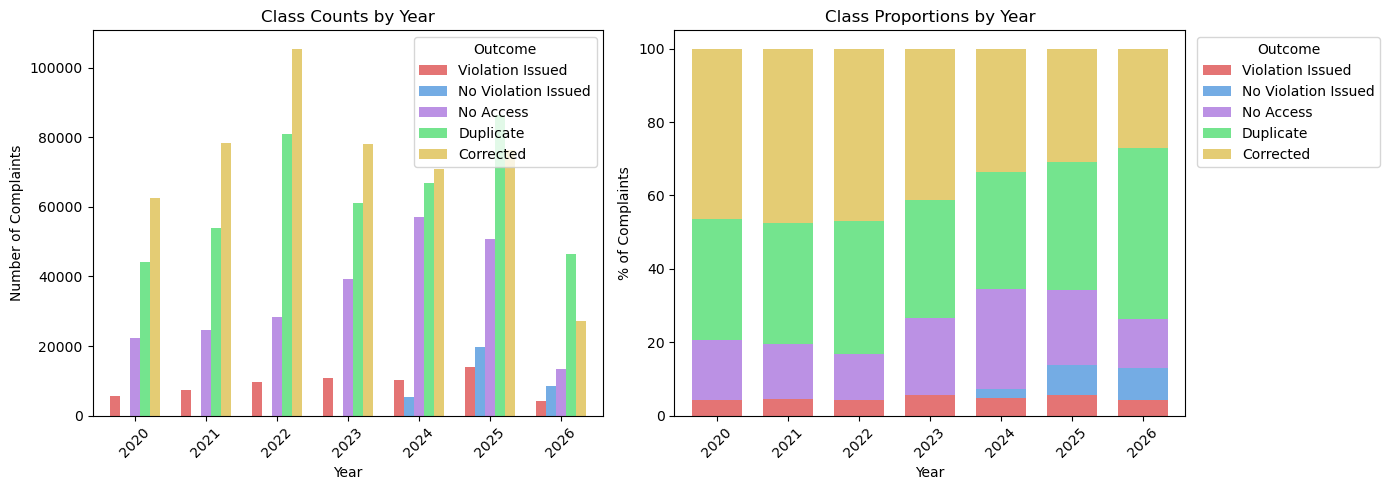

In [3]:
# Class distribution by year (full preprocessed dataset, before train/test split)
dist = pd.DataFrame({"year": year_series.values, "class": y})
dist["class"] = dist["class"].map(dict(enumerate(CLASS_NAMES)))
counts = dist.groupby(["year", "class"]).size().unstack(fill_value=0)
pct = counts.div(counts.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#e05c5c", "#5c9ee0", "#b07ee0", "#5ce07a", "#e0c45c"]

# Raw counts
counts[CLASS_NAMES].plot(kind="bar", ax=axes[0], color=colors, alpha=0.85, width=0.7)
axes[0].set_title("Class Counts by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Complaints")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Outcome")

# Proportions
pct[CLASS_NAMES].plot(kind="bar", stacked=True, ax=axes[1], color=colors, alpha=0.85, width=0.7)
axes[1].set_title("Class Proportions by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("% of Complaints")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Outcome", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig("class_dist_by_year.png", dpi=150)
plt.show()

## Train Random Forest Classifier

In [4]:
# Temporal split: train on 2020-2024, test on 2025
train_mask = year_series.isin([2020, 2021, 2022, 2023, 2024]).values
test_mask  = (year_series == 2025).values

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train: {len(X_train):,} samples (2020–2024)")
print(f"Test:  {len(X_test):,} samples (2025)")

clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

print(classification_report(y_test, clf.predict(X_test), target_names=CLASS_NAMES))

Train: 923,030 samples (2020–2024)
Test:  247,328 samples (2025)
                     precision    recall  f1-score   support

   Violation Issued       0.16      0.01      0.02     14084
No Violation Issued       0.00      0.00      0.00     19865
          No Access       0.33      0.18      0.23     50856
          Duplicate       0.45      0.30      0.36     86233
          Corrected       0.34      0.72      0.46     76290

           accuracy                           0.37    247328
          macro avg       0.26      0.24      0.22    247328
       weighted avg       0.34      0.37      0.32    247328



/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [5]:
# Base rates on the test set (2025) — random-chance baseline per class
test_total = len(y_test)
train_counts = np.bincount(y_train, minlength=5)
train_base_rates = train_counts / train_counts.sum()

print(f"{'Class':<22} {'Test N':>8} {'Test %':>8} {'Train prior':>12} {'Precision@chance':>17}")
print("-" * 72)
for i, name in enumerate(CLASS_NAMES):
    test_n   = (y_test == i).sum()
    test_pct = test_n / test_total
    print(f"{name:<22} {test_n:>8,} {test_pct:>7.1%}  {train_base_rates[i]:>11.1%}  {train_base_rates[i]:>16.1%}")

majority_class = int(train_base_rates.argmax())
majority_acc = (y_test == majority_class).mean()
print(f"\nMajority-class baseline (always predict '{CLASS_NAMES[majority_class]}'):")
print(f"  Accuracy: {majority_acc:.1%}")
print(f"  (model must beat this to be meaningful)")

Class                    Test N   Test %  Train prior  Precision@chance
------------------------------------------------------------------------
Violation Issued         14,084    5.7%         4.8%              4.8%
No Violation Issued      19,865    8.0%         0.6%              0.6%
No Access                50,856   20.6%        18.6%             18.6%
Duplicate                86,233   34.9%        33.3%             33.3%
Corrected                76,290   30.8%        42.8%             42.8%

Majority-class baseline (always predict 'Corrected'):
  Accuracy: 30.8%
  (model must beat this to be meaningful)


## SHAP Analysis

In [ ]:
# Stratified subsample of the test set for SHAP (full test set is too large)
SHAP_SAMPLE_N = 10000
rng = np.random.default_rng(42)

# Sample proportionally per class so all classes are represented
sample_idx = np.concatenate([
    rng.choice(np.where(y_test == c)[0],
               size=max(1, int(SHAP_SAMPLE_N * (y_test == c).mean())),
               replace=False)
    for c in range(len(CLASS_NAMES))
    if (y_test == c).sum() > 0
])
rng.shuffle(sample_idx)

X_shap = X_test.iloc[sample_idx]
y_shap = y_test[sample_idx]

print(f"SHAP sample: {len(X_shap):,} rows (stratified from {len(X_test):,} test rows)")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {(y_shap == i).sum()}")

# TreeExplainer returns one SHAP array per class for multi-class RF
explainer   = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap)   # list of arrays, shape (n_sample, n_features)

print(f"\nNumber of classes: {len(shap_values)}")
print(f"SHAP values shape per class: {shap_values[0].shape}")

SHAP sample: 9,998 rows (stratified from 247,328 test rows)
  Violation Issued: 569
  No Violation Issued: 803
  No Access: 2056
  Duplicate: 3486
  Corrected: 3084


In [ ]:
# --- Bar plot: mean |SHAP| per class side-by-side ---
mean_abs = np.array([np.abs(sv).mean(axis=0) for sv in shap_values])  # (5, n_features)

# Sort features by aggregate importance across all classes
order = mean_abs.mean(axis=0).argsort()[::-1]
sorted_features = [feature_cols[i] for i in order]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(feature_cols))
width = 0.16
colors = ["#e05c5c", "#5c9ee0", "#b07ee0", "#5ce07a", "#e0c45c"]

for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    ax.bar(x + i * width, mean_abs[i][order], width, label=name, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(sorted_features, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Mean |SHAP value|")
ax.set_title("Feature Importance by Outcome Class")
ax.legend()
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150)
plt.show()

In [ ]:
# --- Beeswarm summary plot per class (2x3 grid, last cell hidden) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, name in enumerate(CLASS_NAMES):
    plt.sca(axes.flat[i])
    shap.summary_plot(shap_values[i], X_shap, show=False, plot_size=None)
    axes.flat[i].set_title(f"SHAP Summary — {name}")

axes.flat[-1].set_visible(False)  # hide unused 6th panel

plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150)
plt.show()

In [ ]:
# --- Dependence plots for the top-3 features (by aggregate importance) ---
top3 = [feature_cols[i] for i in order[:3]]

fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(15, 4 * len(CLASS_NAMES)))

for row, (sv, name) in enumerate(zip(shap_values, CLASS_NAMES)):
    for col, feat in enumerate(top3):
        ax = axes[row, col]
        shap.dependence_plot(feat, sv, X_shap, ax=ax, show=False)
        ax.set_title(f"{name} — {feat}", fontsize=9)

plt.tight_layout()
plt.savefig("shap_dependence_top3.png", dpi=150)
plt.show()